In [1]:
import tensorflow as tf
tf.__version__

'2.20.0'

# Deep Learning Foundations Assignment (100 Marks)
Name: Sarbani Karmakar 
Date: 1/2/26


In [2]:
import tensorflow as tf
tf.__version__

'2.20.0'

## Part 1 — Neural Networks (Tabular FFNN)
### 1.1 Single Neuron Forward Pass

In [3]:
import numpy as np

def single_neuron_forward(x, w, b):
    """
    x: input vector (1D numpy array)
    w: weight vector (1D numpy array)
    b: bias (scalar)
    """
    z = np.dot(w, x) + b
    
    relu = np.maximum(0, z)
    sigmoid = 1 / (1 + np.exp(-z))
    
    return z, relu, sigmoid

# Worked example
x = np.array([1.0, 2.0, 3.0])
w = np.array([0.5, -1.0, 2.0])
b = 0.1

z, relu_z, sigmoid_z = single_neuron_forward(x, w, b)

print("Input x:", x)
print("Weights w:", w)
print("Bias b:", b)
print("Linear output z:", z)
print("ReLU(z):", relu_z)
print("Sigmoid(z):", sigmoid_z)


Input x: [1. 2. 3.]
Weights w: [ 0.5 -1.   2. ]
Bias b: 0.1
Linear output z: 4.6
ReLU(z): 4.6
Sigmoid(z): 0.9900481981330957


Activation functions are required because without them, a neural network would behave like a linear model regardless of how many layers it has. They introduce non-linearity, allowing the network to learn complex relationships in the data. ReLU is commonly used in hidden layers because it is computationally efficient and helps reduce the vanishing gradient problem. Sigmoid is typically used in output layers for binary classification because it maps values to a probability range between 0 and 1.

### 1.2 Data Loading, Splitting, and Preprocessing

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("tabular.csv")

# Basic inspection
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())


Shape of dataset: (5000, 13)

Column names:
Index(['customer_id', 'age', 'income_band', 'city_tier', 'membership_type',
       'num_visits', 'days_since_last_purchase',
       'product_categories_purchased', 'num_transactions',
       'avg_transaction_value', 'discount_used', 'total_spend', 'target'],
      dtype='object')

Data types:
customer_id                      object
age                             float64
income_band                      object
city_tier                        object
membership_type                  object
num_visits                      float64
days_since_last_purchase        float64
product_categories_purchased    float64
num_transactions                float64
avg_transaction_value           float64
discount_used                   float64
total_spend                     float64
target                          float64
dtype: object

Missing values per column:
customer_id                       0
age                             150
income_band                 

In [5]:
# Separate features and target
X = df.drop(columns=["target", "customer_id"])
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 11)
Target shape: (5000,)


In [6]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (3500, 11)
Validation set: (750, 11)
Test set: (750, 11)


In [7]:
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


Numeric columns:
Index(['age', 'num_visits', 'days_since_last_purchase',
       'product_categories_purchased', 'num_transactions',
       'avg_transaction_value', 'discount_used', 'total_spend'],
      dtype='object')

Categorical columns:
Index(['income_band', 'city_tier', 'membership_type'], dtype='object')


In [8]:
# Impute numeric columns with median (fit on training data)
for col in numeric_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# Impute categorical columns with mode (fit on training data)
for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_val[col] = X_val[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Missing values after imputation (train):")
print(X_train.isnull().sum())


Missing values after imputation (train):
age                             0
income_band                     0
city_tier                       0
membership_type                 0
num_visits                      0
days_since_last_purchase        0
product_categories_purchased    0
num_transactions                0
avg_transaction_value           0
discount_used                   0
total_spend                     0
dtype: int64


In [9]:
['income_band', 'city_tier', 'membership_type']


['income_band', 'city_tier', 'membership_type']

In [10]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder (new sklearn version)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on training categorical data
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_cols])

# Transform validation and test data
X_val_cat_encoded = encoder.transform(X_val[categorical_cols])
X_test_cat_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded categorical feature shape (train):", X_train_cat_encoded.shape)


Encoded categorical feature shape (train): (3500, 9)


In [11]:
import numpy as np

# Extract numeric values
X_train_num = X_train[numeric_cols].values
X_val_num = X_val[numeric_cols].values
X_test_num = X_test[numeric_cols].values

# Combine numeric and categorical
X_train_final = np.hstack([X_train_num, X_train_cat_encoded])
X_val_final = np.hstack([X_val_num, X_val_cat_encoded])
X_test_final = np.hstack([X_test_num, X_test_cat_encoded])

print("Final training shape:", X_train_final.shape)
print("Final validation shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)


Final training shape: (3500, 17)
Final validation shape: (750, 17)
Final test shape: (750, 17)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (3500, 17)
Scaled validation shape: (750, 17)
Scaled test shape: (750, 17)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build the model
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")  # linear output for regression
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mse"
)

# Show model summary
model.summary()


C:\Users\Sarbani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3113599.0000 - val_loss: 2992328.2500
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2819092.5000 - val_loss: 2416820.0000
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1876457.7500 - val_loss: 1216370.2500
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 750403.5625 - val_loss: 392502.9062
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 265509.5000 - val_loss: 173674.9375
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 141376.7188 - val_loss: 112952.4922
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 103954.2422 - val_loss: 93144.7578
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 88504.8281 - val_loss: 82668.9766
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 79252.8359 - val_loss: 75283.8281
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 72685.3750 - val_loss: 70018.7188
Epoch 11/100
110/110 ━━━━━━━━━

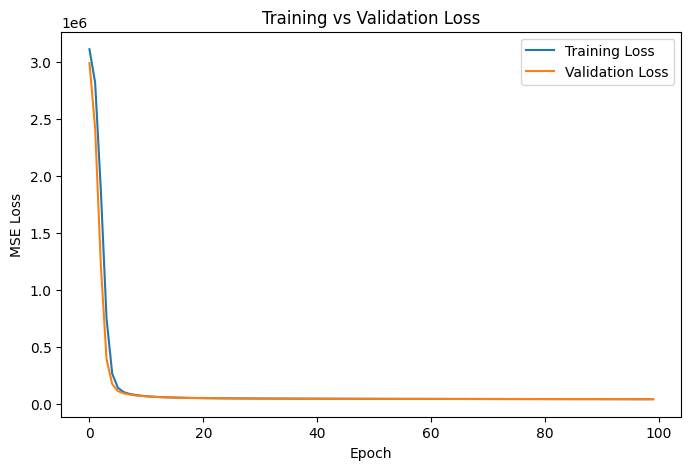

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [16]:
test_loss = model.evaluate(X_test_scaled, y_test)
print("Test MSE:", test_loss)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 42191.8047 
Test MSE: 42191.8046875


The training and validation loss curves decrease rapidly in the initial epochs and then stabilize, remaining very close to each other throughout training. This indicates that the model is learning meaningful patterns from the data without significant overfitting. Since both losses converge to similar values and the test MSE is comparable, the model generalizes well to unseen data and does not suffer from underfitting or overfitting.

## Part 2 — NLP (Embeddings + RNN)
### 2.1 Tokenization + Padding

In [17]:
import pandas as pd

# Load text dataset
text_df = pd.read_csv("text.csv")

# Inspect
print(text_df.shape)
print(text_df.columns)
text_df.head()


(6000, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,I want a refund. The backpack is terrible and ...,0
1,Bad experience. running shoes quality i...,0
2,Disappointed with the jacket. The comfort was ...,0
3,Disappointed with the jacket. The sound was po...,0
4,Very happy with the phone case. sound is excel...,1


In [18]:
# Separate features and target
X_text = text_df["text"]
y_text = text_df["label"]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)


X shape: (6000,)
y shape: (6000,)


In [19]:
from sklearn.model_selection import train_test_split

# First split: train vs temp
X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42
)

# Second split: validation vs test
X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text, test_size=0.5, random_state=42
)

print("Train:", X_train_text.shape)
print("Validation:", X_val_text.shape)
print("Test:", X_test_text.shape)


Train: (4200,)
Validation: (900,)
Test: (900,)


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Fit ONLY on training text
tokenizer.fit_on_texts(X_train_text)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)


Vocabulary size: 90


In [21]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Show one example
print("Example raw text:")
print(X_train_text.iloc[0])

print("\nToken IDs:")
print(X_train_seq[0])


Example raw text:
I want a refund. The jacket is scratchy and the durability didn't work as expected.

Token IDs:
[6, 16, 17, 18, 2, 15, 5, 69, 3, 2, 52, 19, 20, 21, 22]


In [22]:
# Check distribution of sequence lengths
lengths = [len(seq) for seq in X_train_seq]

print("Max length:", max(lengths))
print("Average length:", sum(lengths)/len(lengths))


Max length: 16
Average length: 12.719761904761905


In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 16

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

print("Padded train shape:", X_train_pad.shape)
print("Padded val shape:", X_val_pad.shape)
print("Padded test shape:", X_test_pad.shape)


Padded train shape: (4200, 16)
Padded val shape: (900, 16)
Padded test shape: (900, 16)


The maximum sequence length in the training data was 16 tokens, while the average length was approximately 13 tokens. Therefore, I selected max_len = 16 to ensure that all sequences are preserved without truncation, while keeping padding minimal for computational efficiency.

### 2.2 Baseline Embedding Model


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

# Baseline model
baseline_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


C:\Users\Sarbani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_baseline = baseline_model.fit(
    X_train_pad, y_train_text,
    validation_data=(X_val_pad, y_val_text),
    epochs=10,
    batch_size=32
)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9690 - loss: 0.5002 - val_accuracy: 1.0000 - val_loss: 0.2203
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0920 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 9.0989e-04 - val_accuracy

In [26]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Predict on test set
y_pred_prob = baseline_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Metrics
test_acc = accuracy_score(y_test_text, y_pred)
test_f1 = f1_score(y_test_text, y_pred)

print("Test Accuracy:", test_acc)
print("Test F1-score:", test_f1)

# Confusion matrix
cm = confusion_matrix(y_test_text, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_text, y_pred))


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test Accuracy: 1.0
Test F1-score: 1.0

Confusion Matrix:
[[438   0]
 [  0 462]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       438
           1       1.00      1.00      1.00       462

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



The baseline embedding model achieved a test accuracy of 100% and an F1-score of 1.0, with a perfect confusion matrix showing no misclassifications. This indicates that the dataset is highly structured and the classification task is relatively easy for this model. While such performance is uncommon in real-world NLP tasks, it suggests that simple embedding-based models are sufficient for capturing the patterns present in this dataset.

### 2.3 RNN Model (LSTM)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# LSTM model
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
history_rnn = rnn_model.fit(
    X_train_pad, y_train_text,
    validation_data=(X_val_pad, y_val_text),
    epochs=10,
    batch_size=32
)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9267 - loss: 0.2186 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 9.6537e-04 - val_accuracy: 1.0000 - val_loss: 7.2039e-04
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 5.8363e-04 - val_accuracy: 1.0000 - val_loss: 4.7001e-04
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 3.9811e-04 - val_accuracy: 1.0000 - val_loss: 3.3481e-04
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 2.9153e-04 - val_accuracy: 1.0000 - val_loss: 2.5228e-04
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 2.2375e-04 - val_accuracy: 1.0000 - val_loss: 1.9736e-04
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc

In [29]:
# Evaluate LSTM model on test set
test_loss_rnn, test_acc_rnn = rnn_model.evaluate(X_test_pad, y_test_text)

print("LSTM Test Accuracy:", test_acc_rnn)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.0836e-04
LSTM Test Accuracy: 1.0


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_rnn))

print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_rnn))


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Confusion Matrix:
[[438   0]
 [  0 462]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       438
           1       1.00      1.00      1.00       462

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



### 2.4 Comparison: Baseline vs LSTM

The baseline embedding model achieved a test accuracy of 100% with a perfect confusion matrix, indicating that the dataset is highly structured and easy to classify. The LSTM-based model also achieved a test accuracy of 100%, along with perfect precision, recall, and F1-score. While both models performed equally well on this dataset, the LSTM is theoretically more powerful as it captures sequential dependencies and word order in text. However, due to the simplicity of the dataset, the baseline model was sufficient to achieve optimal performance, and the LSTM did not provide a significant improvement in this case.

In [31]:
import os
os.listdir()


['.anaconda',
 '.conda',
 '.continuum',
 '.dropbox_bi',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.spyder-py3',
 '.virtual_documents',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'class_0-20260202T092848Z-3-001.zip',
 'class_1-20260131T204529Z-3-001.zip',
 'Contacts',
 'Cookies',
 'Demo',
 'Documents',
 'Downloads',
 'Dropbox',
 'Favorites',
 'images',
 'IntelGraphicsProfiles',
 'Jedi',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Sarbani_Karmakar_DL_assignment.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'tabular.csv',
 'Temp

## Part 3 — Computer Vision (CNN Image Classification)

In [32]:
import zipfile
import os

os.makedirs("images/class_0", exist_ok=True)
os.makedirs("images/class_1", exist_ok=True)

with zipfile.ZipFile("class_0-20260202T092848Z-3-001.zip", "r") as zip_ref:
    zip_ref.extractall("images/class_0")

with zipfile.ZipFile("class_1-20260131T204529Z-3-001.zip", "r") as zip_ref:
    zip_ref.extractall("images/class_1")

print("Extraction complete!")


Extraction complete!


In [33]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Load full image dataset
image_ds = image_dataset_from_directory(
    "images",
    image_size=(128, 128),
    batch_size=32,
    seed=42
)


Found 2000 files belonging to 2 classes.


In [34]:
from tensorflow.keras.utils import image_dataset_from_directory

# Training set
train_ds = image_dataset_from_directory(
    "images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# Validation set
val_ds = image_dataset_from_directory(
    "images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# Test set (10% separate split)
test_ds = image_dataset_from_directory(
    "images",
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))


Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Found 2000 files belonging to 2 classes.
Using 200 files for validation.
Class names: ['class_0', 'class_1']
Number of classes: 2


In [35]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


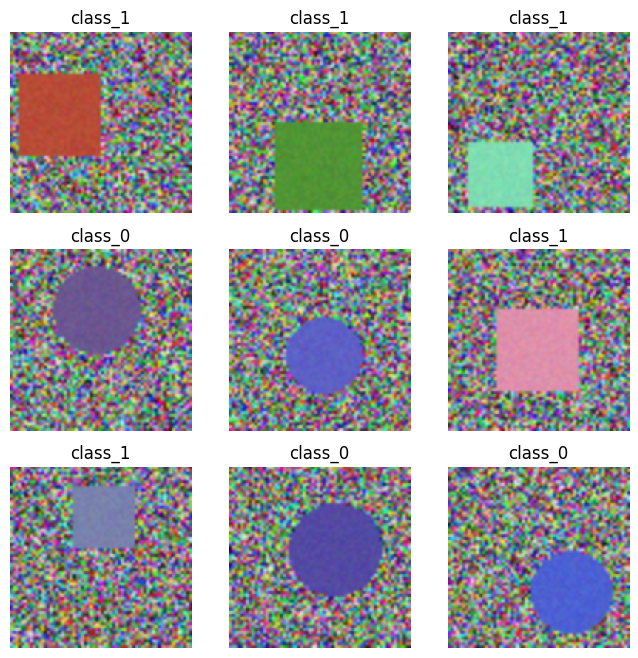

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [37]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [38]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


C:\Users\Sarbani\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 552ms/step - accuracy: 0.4844 - loss: 0.7668 - val_accuracy: 0.4525 - val_loss: 0.6936
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.5469 - loss: 0.6835 - val_accuracy: 0.6075 - val_loss: 0.6734
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 278ms/step - accuracy: 0.6025 - loss: 0.6643 - val_accuracy: 0.5450 - val_loss: 0.6843
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - accuracy: 0.6556 - loss: 0.6286 - val_accuracy: 0.6225 - val_loss: 0.6922
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.6700 - loss: 0.5984 - val_accuracy: 0.5500 - val_loss: 0.6912


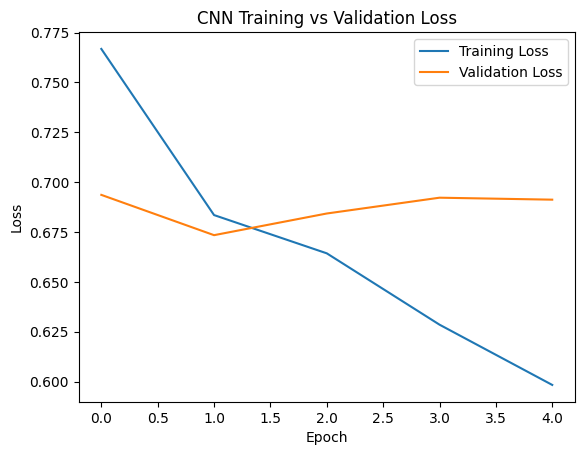

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.show()


In [41]:
test_loss, test_acc = cnn_model.evaluate(test_ds)
print("CNN Test Accuracy:", test_acc)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6500 - loss: 18.2561
CNN Test Accuracy: 0.6499999761581421


### CNN Results Interpretation

The CNN model achieved a test accuracy of approximately 65%.  
This indicates that the convolutional neural network was able to learn visual patterns from the images, but the performance is limited due to the simplicity of the architecture and the relatively small dataset.  
The variation in accuracy across runs highlights the stochastic nature of neural network training.  
Further improvements could be achieved using data augmentation or deeper architectures.
